# Jaguar Re-ID — ViT Improved v6

**Architecture** : identique a v5 (ViT + `relu`, `embed_dim=64`, 3 blocs, `AdamW(wd=1e-4)`, Dropout(0.1) sur l'embedding). On isole l'effet du **label smoothing**.

### Diagnostic v5 (point de depart)

| Metrique | Valeur | Commentaire |
|----------|--------|-------------|
| Val Acc | 59.37 % | Regression vs v4 (72.30 %) |
| Train Acc | 77.64 % | Memorisation reduite vs v4 (98.42 %) |
| Gap train/val | **18.3 pts** | **Reduit** (v3: 20.4, v4: 26.1) -- le dropout regularise |
| Retrain train acc | 95.99 % | Regularise (v4: 100 %) |
| Similarity mean (test) | **0.22** | **Tres bas** -- distribution ecrasee (v4: 0.81, ResNet v6: 0.62) |
| Similarity range (test) | [0.00, 0.999] | Etalee, queue longue vers 0 |
| Kaggle pub / priv | 0.253 / 0.241 | -4 % / -11 % vs v4 (0.264 / 0.271) |

v5 a reussi sur l'aspect **regularisation structurelle** (gap reduit, retrain regularise) mais la **geometrie des embeddings s'est deplacee** : ReLU + Dropout produit des embeddings sparses -> cosinus des vecteurs normalises concentres pres de 0. C'est l'inverse du probleme de v4 (saturation haute).

### Comparaison avec le ResNet v6 (gold standard, Kaggle 0.630)

Le ResNet v6 utilise **`label_smoothing=0.1`** et obtient :
- Similarity mean = 0.62 (v ViT v5 : 0.22)
- Similarity std = 0.12 (v ViT v5 : ~0.20)
- Distribution en cloche bien centree

C'est la technique qui a fait la difference (+0.06 Kaggle vs 06_2 sans label smoothing).

### Changement v6 : label smoothing (« noisy targets » du cours)

| Changement | Probleme vise | Raisonnement |
|-----------|--------------|--------------|
| `sparse_categorical_crossentropy` -> `CategoricalCrossentropy(label_smoothing=0.1)` | Distribution des similarites ecrasee en v5 (mean=0.22), sur-confiance residuelle du modele (retrain 96 %) | Le label smoothing remplace les cibles `one-hot` dures (1.0 / 0.0) par des distributions adoucies (0.9 / 0.003). Le modele apprend a ne pas saturer le softmax → les embeddings sont mieux calibres, moins sparses (meme avec ReLU), et la distribution de similarites est recentree. C'est la technique du cours qui a porte le ResNet v6 a Kaggle 0.630. |

**On garde** : AdamW(wd=1e-4) + Dropout(0.1) de v5, meme architecture, meme fix retrain.

**Effet attendu** :
- Similarity mean remonte de 0.22 vers ~0.5+ (moins sparse)
- Distribution en cloche plus centree
- Kaggle en hausse vs v5 (idealement >= v4 0.264)
- Gap train/val reste autour de 18 pts (le label smoothing regularise differemment)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776604371.209684   89984 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776604371.242908   89984 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776604372.014250   89984 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776604372.715667   89984 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v6'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters (identique a v3/v4/v5)
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (fix de v2)

# Regularisation heritee de v4/v5
WEIGHT_DECAY = 1e-4  # AdamW decoupled weight decay
DROPOUT_RATE = 0.1   # dropout sur l'embedding uniquement (hors residuels)

# Regularisation v6 : label smoothing ("noisy targets" du cours)
# v5 a montre que le dropout reduit le gap mais ecrase les similarites (mean=0.22).
# Label smoothing empeche le softmax de saturer → embeddings mieux calibres,
# distribution de similarites recentree (cf. ResNet v6 : mean=0.62, Kaggle 0.630).
LABEL_SMOOTHING = 0.1

# Retrain fix (herite de v3, garde a 60 apres le probleme d'over-retrain de v5)
RETRAIN_EPOCHS_MULTIPLIER = 4    # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding pour label smoothing (CategoricalCrossentropy)
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

train_ds = make_dataset(X_train, y_train_oh, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val,   y_val_oh)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776604375.379988   89984 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776604375.476187   89984 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture **identique a v5** — seul le label smoothing change (cote loss).

| Parametre | v5 | v6 | Pourquoi |
|-----------|----|----|----------|
| Architecture | ViT + relu + Dropout(0.1) embedding | idem | On isole l'effet du label smoothing |
| Optimizer | `AdamW(wd=1e-4)` | idem | On garde AdamW |
| Dropout | 0.1 sur l'embedding | idem | On garde la regularisation structurelle |
| **Loss** | `sparse_categorical_crossentropy` | **`CategoricalCrossentropy(label_smoothing=0.1)`** | **noisy targets** du cours : adoucit les cibles (1.0/0.0 → 0.9/0.003) |
| Retrain epochs | `max(4*BEST_EPOCH, 60)` | idem | Fix retrain de v3 |

### Effet attendu du label smoothing

Le softmax cible n'est plus `[0, 0, ..., 1, ..., 0]` (one-hot dur) mais `[0.003, ..., 0.9, ..., 0.003]` (adouci).

- Le modele ne cherche plus a saturer son softmax → il produit des logits plus moderes.
- Les features apprises (avant softmax) sont mieux calibrees, moins concentrees sur quelques dimensions dominantes.
- Les embeddings normalises couvrent mieux la sphere unite → **similarites mieux distribuees** (ni ecrasees a 0 comme v5, ni saturees a 1 comme v4).

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks (identique a v4/v5, PAS de dropout dans les blocs)
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head — DROPOUT UNIQUEMENT ICI (idem v5)
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v5 avec `BEST_LR=5e-4`. Le label smoothing peut decaler encore le LR optimal (les cibles etant moins exigeantes, le LR peut etre un peu plus grand).

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, label_smoothing={LABEL_SMOOTHING}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v6, wd=0.0001, dropout=0.1, label_smoothing=0.1) ===


I0000 00:00:1776604381.846310   90084 service.cc:153] XLA service 0x7f52080575f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776604381.846348   90084 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776604381.921535   90084 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776604382.481738   90084 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776604382.553691   90084 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10790__.105
I0000 00:00:1776604382.644817   90084 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set inste

  lr_0.01: val_acc=0.0950 (best epoch=38)


I0000 00:00:1776604440.557665   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59708__.105
I0000 00:00:1776604444.649369   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59708__.105
I0000 00:00:1776604448.163734   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61105__.30
I0000 00:00:1776604449.253663   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61105__.30


  lr_0.001: val_acc=0.1082 (best epoch=59)


I0000 00:00:1776604485.279976   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_125671__.105
I0000 00:00:1776604489.264302   90081 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_125671__.105
I0000 00:00:1776604492.608349   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127068__.30
I0000 00:00:1776604493.729733   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127068__.30


  lr_0.0005: val_acc=0.8232 (best epoch=95)


I0000 00:00:1776604545.543378   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216051__.105
I0000 00:00:1776604549.559086   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216051__.105
I0000 00:00:1776604552.811922   90081 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_217448__.30
I0000 00:00:1776604553.913541   90081 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_217448__.30


  lr_0.0001: val_acc=0.0950 (best epoch=1)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0005,0.823219,95
1,lr_0.001,0.108179,59
2,lr_0.01,0.094987,38
3,lr_0.0001,0.094987,1



Best: lr_0.0005 → val_acc=0.8232
BEST_LR = 0.0005, BEST_EPOCH = 95


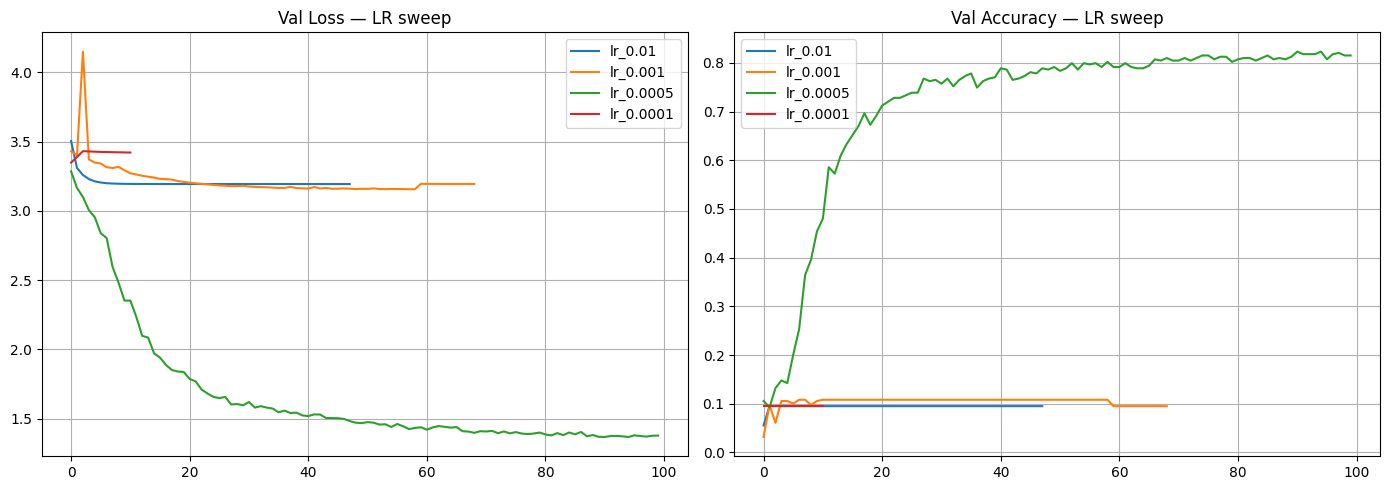

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776604563.244028   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235566__.105


42/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0409 - loss: 28.8836

I0000 00:00:1776604567.370427   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235566__.105


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.0442 - loss: 26.9791

I0000 00:00:1776604570.674928   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236963__.30
I0000 00:00:1776604571.798662   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236963__.30


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.0679 - loss: 13.2043 - val_accuracy: 0.0844 - val_loss: 3.2881 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0693 - loss: 3.2986 - val_accuracy: 0.1372 - val_loss: 3.1715 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1082 - loss: 3.2632 - val_accuracy: 0.1478 - val_loss: 3.1349 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1141 - loss: 3.2449 - val_accuracy: 0.1187 - val_loss: 3.2321 - learning_rate: 5.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1418 - loss: 3.1919 - val_accuracy: 0.1689 - val_loss: 3.1495 - learning_rate: 5.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1603 - loss: 3.1171 - val_accuracy: 0.1451 - val_loss: 3.0572 - learning_rate: 5.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1834 - 

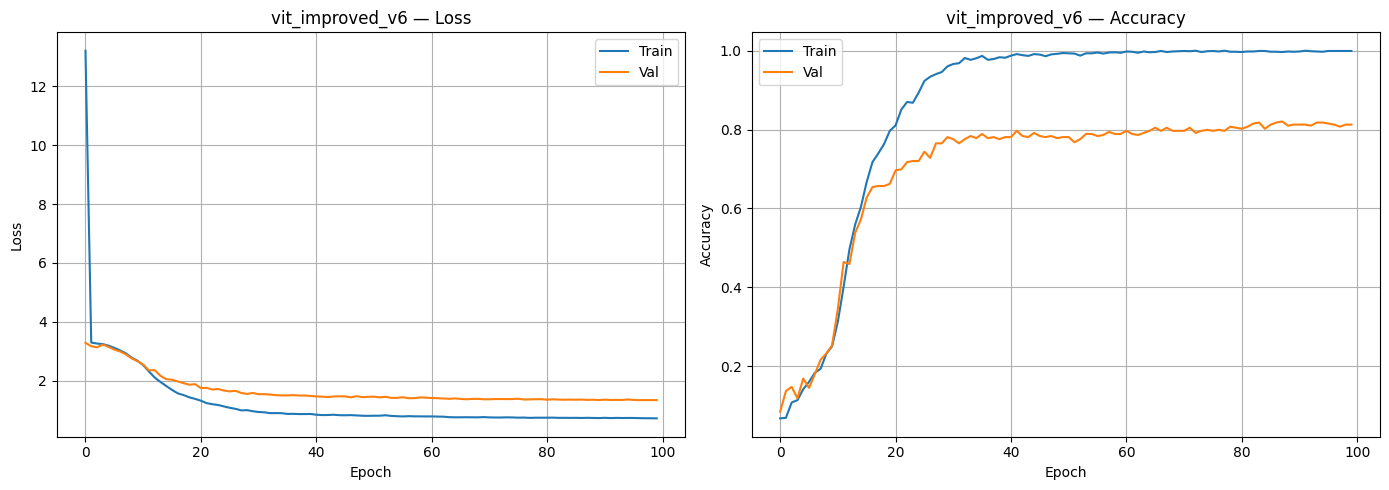

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1, v5: 18.3)")
print(f"  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)")

I0000 00:00:1776604664.884250   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236963__.30
I0000 00:00:1776604665.121474  115364 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776604665.507068  115372 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 80 bytes spill stores, 80 bytes spill loads



vit_improved_v6 (best LR=0.0005, wd=0.0001, dropout=0.1, ls=0.1):
  Train — Loss: 0.6825, Acc: 1.0000
  Val   — Loss: 1.3428, Acc: 0.8127
  Gap train/val: 18.7 pts  (v3: 20.4, v4: 26.1, v5: 18.3)
  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)


I0000 00:00:1776604665.394129   90082 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_954554__.21
I0000 00:00:1776604666.493149   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_955045__.21


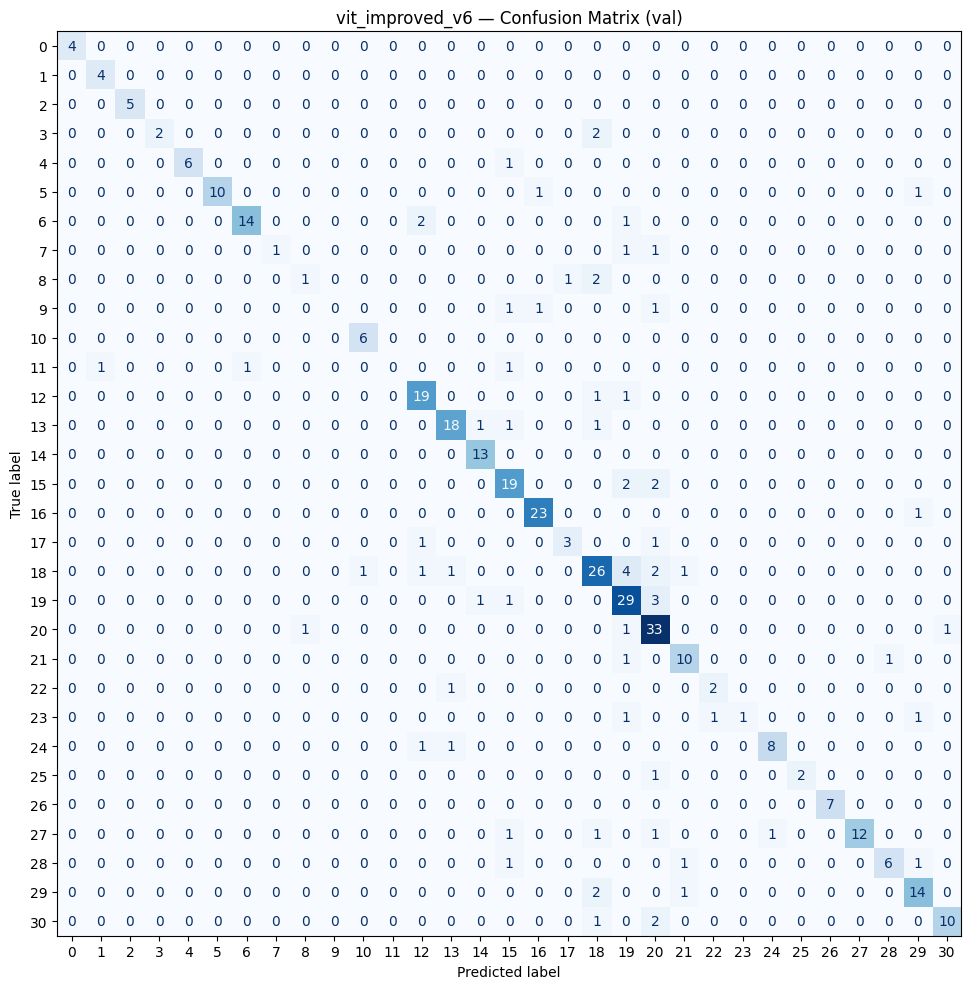

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

On garde le **fix retrain de v3** : `max(4*BEST_EPOCH, 60)` epochs.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)
all_ds = make_dataset(X_all, y_all_oh, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 95
RETRAIN_EPOCHS      : 380  (= max(95*4, 60))
Retraining on full dataset (1895 images) for 380 epochs
Epoch 1/380


I0000 00:00:1776604673.354724   90084 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_965448__.105


54/60 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0519 - loss: 25.2027

I0000 00:00:1776604677.789303   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_965448__.105
I0000 00:00:1776604678.089498  115638 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776604678.383366  115637 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776604678.417037  115638 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776604679.100369  115629 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_74', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776604679.192240  115627 subprocess_compilat

60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.0623 - loss: 11.4976
Epoch 2/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0739 - loss: 3.3585
Epoch 3/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0871 - loss: 3.3433
Epoch 4/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0908 - loss: 3.2830
Epoch 5/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1256 - loss: 3.1488
Epoch 6/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1573 - loss: 3.0108
Epoch 7/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1615 - loss: 2.9557
Epoch 8/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2311 - loss: 2.7944
Epoch 9/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2517 - loss: 2.7103
Epoch 10/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3277 - loss: 2.5584
Epoch 11/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3720 - loss: 2.4229
Epoch 12/380
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4185

I0000 00:00:1776604885.100708   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1257712__.30
I0000 00:00:1776604886.384332   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1257712__.30
I0000 00:00:1776604886.610772  129760 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776604886.977341  129764 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 84 bytes spill stores, 84 bytes spill loads




Final retrain train acc: 1.0000


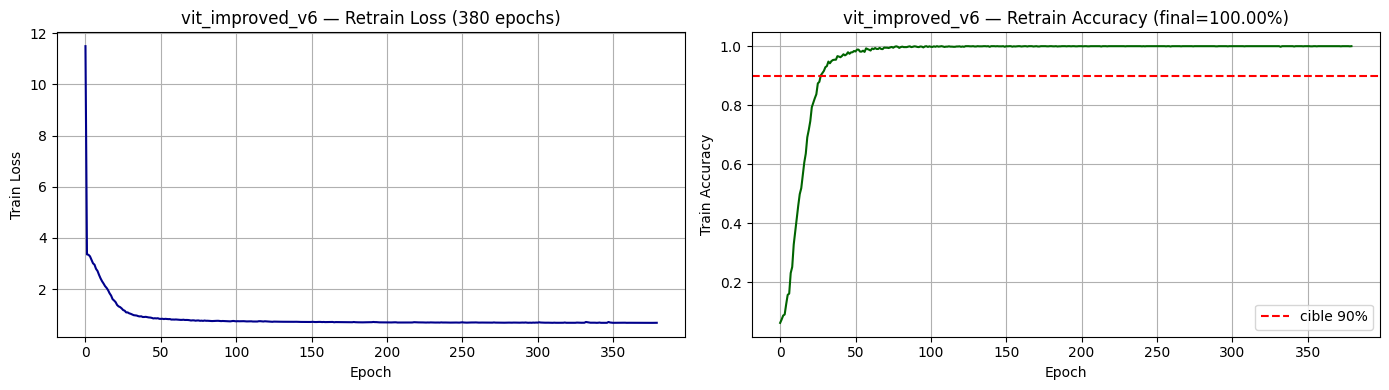

✅ Retrain converge : train acc = 100.00%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le dropout peut avoir regularise fortement -- c'est OK si la courbe monte regulierement. Verifier la courbe.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776604888.711372   90083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1258458__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 10s 992ms/step

I0000 00:00:1776604889.721233   90085 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1258925__.19
I0000 00:00:1776604889.901861  129892 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776604890.049539  129890 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776604890.270380  129886 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776604890.400067  129887 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776604890.850317  129885 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 363ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v6.csv


,row_id,similarity
0,0,0.602909
1,1,0.701852
2,2,0.472982
3,3,0.707992
4,4,0.657835


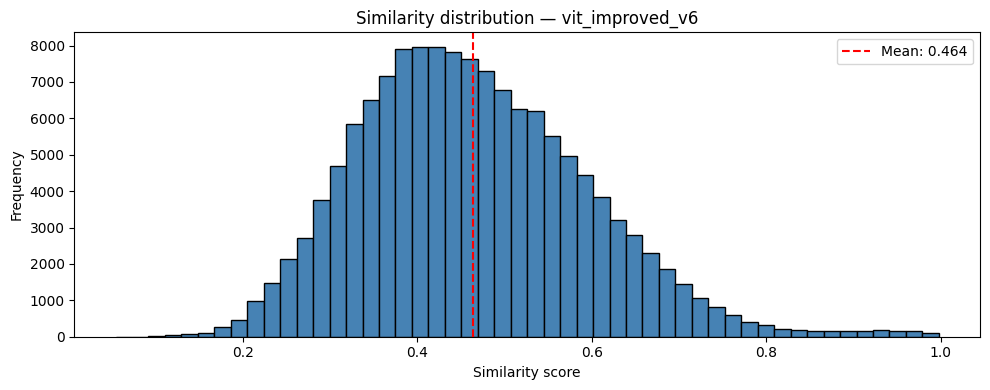

Similarity mean: 0.4643
Similarity std : 0.1310
Similarity min : 0.0540
Similarity max : 0.9979


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [17]:
print(f"""
ViT Improved v6 (AdamW + wd={WEIGHT_DECAY} + Dropout={DROPOUT_RATE} + LabelSmoothing={LABEL_SMOOTHING}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1, v5: 18.3)
  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}, Dropout: {DROPOUT_RATE}, LabelSmoothing: {LABEL_SMOOTHING}
  Activation: {ACTIVATION}, Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_train_acc:.2%}
  Embedding dim: {test_embeddings.shape[1]}
  Similarity mean: {similarities.mean():.4f}  (v4: 0.81, v5: 0.22, ResNet v6: 0.62)
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")


ViT Improved v6 (AdamW + wd=0.0001 + Dropout=0.1 + LabelSmoothing=0.1):
  Train - Loss: 0.6825, Acc: 1.0000
  Val   - Loss: 1.3428, Acc: 0.8127
  Gap train/val: 18.7 pts  (v3: 20.4, v4: 26.1, v5: 18.3)
  LR: 0.0005, Weight decay: 0.0001, Dropout: 0.1, LabelSmoothing: 0.1
  Activation: relu, Embed dim: 64, Blocks: 3
  Best Epoch: 95 / Retrain Epochs: 380
  Retrain train acc: 100.00%
  Embedding dim: 260
  Similarity mean: 0.4643  (v4: 0.81, v5: 0.22, ResNet v6: 0.62)
  Similarity range: [0.0540, 0.9979]



### Results

| Metrique | v4 (AdamW) | v5 (+ Dropout) | v6 (+ LabelSmoothing) |
|----------|------------|-----------------|------------------------|
| Architecture | ViT + relu | ViT + relu (idem) | ViT + relu (idem) |
| Regularisation | AdamW(wd=1e-4) | + Dropout(0.1) embedding | + LabelSmoothing(0.1) |
| BEST_LR | 1e-4 | 5e-4 | TODO |
| BEST_EPOCH (sweep) | 18 | 16 | TODO |
| Train accuracy (sweep) | 98.42 % | 77.64 % | TODO |
| Val accuracy (sweep) | 72.30 % | 59.37 % | TODO |
| Gap train/val | 26.1 pts | 18.3 pts | TODO |
| Retrain train acc | 100.00 % | 95.99 % | TODO |
| Similarity mean | 0.8086 | 0.2217 | TODO |
| Similarity range | [0.398, 0.999] | [0.000, 0.999] | TODO |
| Kaggle public | 0.264 | 0.253 | TODO |
| Kaggle private | 0.271 | 0.241 | TODO |

### Analysis

- TODO : Similarity mean a-t-elle remonte de 0.22 vers ~0.5+ ? -> indicateur direct de l'effet du label smoothing sur la calibration des embeddings
- TODO : Distribution en cloche centree comme ResNet v6 (mean=0.62, std=0.12) ou encore trop ecrasee ?
- TODO : Kaggle vs v5 (0.253 / 0.241) : en hausse = label smoothing recentre la distribution. Si >= v4 (0.264) = on est revenu au meilleur score. Si >= 0.30 = saut significatif.
- TODO : Gap train/val : le label smoothing peut le faire remonter (la cible n'est plus 1.0, donc train_acc calculee sur argmax peut paraitre elevee meme avec une loss plus haute). Ce n'est pas grave si le Kaggle progresse.
- TODO : BEST_LR a-t-il encore bouge ? 1e-4 (v4) -> 5e-4 (v5) -> ? (v6)

### Verdict

- [ ] Improvable -> Instructions for v7 (data augmentation probablement, ou label_smoothing plus fort)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff cette technique, why ?

### Interpretation

_Free Space : points cles pour la soutenance._

- **Label smoothing = "noisy targets" du cours.** Symetrique du dropout (qui etait une noise structurelle sur les activations) : ici on met du bruit sur les cibles.
- **Effet sur la geometrie des embeddings** : le modele cesse de pousser les logits a l'infini → les features du penultimate layer sont mieux calibrees → les embeddings normalises sont repartis plus uniformement sur la sphere → similarites mieux distribuees.
- **ResNet paralle** : ResNet v6 est passe de 0.566 (sans ls) a 0.630 (avec ls=0.1). Le gain principal sur le ResNet vient de la calibration. Meme mecanisme attendu sur ViT.
- **Combinaison cours-friendly** : AdamW (wd) + Dropout (dropout des activations) + Label smoothing (bruit sur cible) = triptyque classique du cours de regularisation. Si ca ne suffit pas : v7 ajoutera data augmentation ("noisy inputs").